## Domain Shift Visualization (KR vs JMDC/UKB)


In [2]:
import math
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import textwrap


font_path = "figutils/Helvetica.ttf"
fm.fontManager.addfont(font_path)

prop = fm.FontProperties(fname=font_path)
font_name = prop.get_name()
print(font_name)

plt.rcParams["font.family"] = font_name

import sys
sys.path.append('..')
from utils import get_p2i_composite

try:
    from scipy.stats import wasserstein_distance
except Exception:
    wasserstein_distance = None

from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

# plt.style.use('default')
np.random.seed(42)


Helvetica


In [3]:
PROJECT_ROOT = Path.cwd().resolve()
DATA_ROOT = (PROJECT_ROOT / '../../data').resolve()

# 필요 시 경로만 바꿔서 재사용하세요.
DOMAIN_PATHS = {
    # 'kr_train': DATA_ROOT / 'dose/kr_train.bin',
    # 'kr_val': DATA_ROOT / 'dose/kr_val.bin',
    # 'kr_test': DATA_ROOT / 'dose/kr_test.bin',
    'KOR': DATA_ROOT / 'kr_all.bin',
    'JMDC': DATA_ROOT / 'JMDC_extval.bin',
    'UKB': DATA_ROOT / 'UKB_extval.bin',
}

INCLUDE_UKB = True

print('PROJECT_ROOT:', PROJECT_ROOT)
print('DATA_ROOT   :', DATA_ROOT)
for k, v in DOMAIN_PATHS.items():
    print(f'{k:>8}: {v} | exists={v.exists()}')


PROJECT_ROOT: /home/hsh/hsh/GPT-Disease-Drug-Prediction/figure
DATA_ROOT   : /home/hsh/hsh/data
     KOR: /home/hsh/hsh/data/kr_all.bin | exists=True
    JMDC: /home/hsh/hsh/data/JMDC_extval.bin | exists=True
     UKB: /home/hsh/hsh/data/UKB_extval.bin | exists=True


In [4]:
COMPOSITE_DTYPE = np.dtype([
    ('ID', np.uint32),
    ('AGE', np.uint32),
    ('DATA', np.uint32),
    ('SHIFT', np.uint32),
    ('TOTAL', np.uint32),
])

DRUG_TOKEN_MIN = 1278  # apply_token_shift=False 기준
DRUG_TOKEN_MAX = 1288

def load_domain(path: Path):
    arr = np.fromfile(path, dtype=COMPOSITE_DTYPE)
    p2i = get_p2i_composite(arr)
    return arr, p2i

def js_divergence(p, q, eps=1e-12):
    p = np.asarray(p, dtype=np.float64)
    q = np.asarray(q, dtype=np.float64)
    p = p / max(p.sum(), eps)
    q = q / max(q.sum(), eps)
    m = 0.5 * (p + q)
    def _kl(a, b):
        a = np.clip(a, eps, None)
        b = np.clip(b, eps, None)
        return np.sum(a * np.log(a / b))
    return 0.5 * _kl(p, m) + 0.5 * _kl(q, m)

def normalized_hist(x, bins):
    h, _ = np.histogram(x, bins=bins)
    h = h.astype(np.float64)
    s = h.sum()
    return h / s if s > 0 else h


In [5]:
domains = {}
for name, path in DOMAIN_PATHS.items():
    if (not INCLUDE_UKB) and name == 'ukb':
        continue
    if not path.exists():
        print(f'[skip] {name}: missing {path}')
        continue
    data, p2i = load_domain(path)
    domains[name] = {'data': data, 'p2i': p2i, 'path': path}
    print(f'[ok] {name}: events={len(data):,}, patients={len(p2i):,}')

assert 'KOR' in domains, 'KOR is required as reference domain.'


[ok] KOR: events=25,699,691, patients=107,658
[ok] JMDC: events=333,957,912, patients=2,197,367
[ok] UKB: events=1,596,561, patients=51,072


In [6]:
def summarize_domain(data, p2i):
    ages = data['AGE'].astype(np.float64) / 365.25
    dose = data['SHIFT'].astype(np.int64)
    dur = data['TOTAL'].astype(np.int64)
    token = data['DATA'].astype(np.int64)
    drug_mask = (token >= DRUG_TOKEN_MIN) & (token <= DRUG_TOKEN_MAX)

    lengths = p2i[:, 1].astype(np.int64) if len(p2i) > 0 else np.array([0])
    pos_dose = dose[dose > 0]

    out = {
        'n_events': int(len(data)),
        'n_patients': int(len(p2i)),
        'events_per_patient_mean': float(lengths.mean()),
        'events_per_patient_median': float(np.median(lengths)),
        'age_mean': float(ages.mean()),
        'age_std': float(ages.std()),
        'age_p95': float(np.percentile(ages, 95)),
        'dose_mean': float(dose.mean()),
        'dose_nonzero_rate': float((dose > 0).mean()),
        'dose_positive_mean': float(pos_dose.mean()) if len(pos_dose) else 0.0,
        'duration_mean': float(dur.mean()),
        'duration_p95': float(np.percentile(dur, 95)),
        'drug_event_rate': float(drug_mask.mean()),
        'unique_data_tokens': int(np.unique(token).size),
    }
    return out

summary_rows = []
for name, obj in domains.items():
    row = {'domain': name}
    row.update(summarize_domain(obj['data'], obj['p2i']))
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows).set_index('domain').sort_index()
summary_df


,n_events,n_patients,events_per_patient_mean,events_per_patient_median,age_mean,age_std,age_p95,dose_mean,dose_nonzero_rate,dose_positive_mean,duration_mean,duration_p95,drug_event_rate,unique_data_tokens
domain,,,,,,,,,,,,,,
JMDC,333957912,2197367,151.980944,86.0,53.493037,10.577715,69.166324,0.187743,0.094800,1.980410,3.138407,30.0,0.094827,1159
KOR,25699691,107658,238.716036,190.0,64.765015,12.193031,82.154689,0.439798,0.223737,1.965689,7.073512,30.0,0.224016,1192
UKB,1596561,51072,31.260984,28.0,59.350964,16.042240,77.716632,0.000000,0.000000,0.000000,0.000000,0.0,0.025849,1206


In [44]:
color_map = {
    'KOR': '#558387',
    'JMDC': '#bb372a',
    'UKB': "#ce9c3e",
}

## 1) AGE / trajectory length distribution

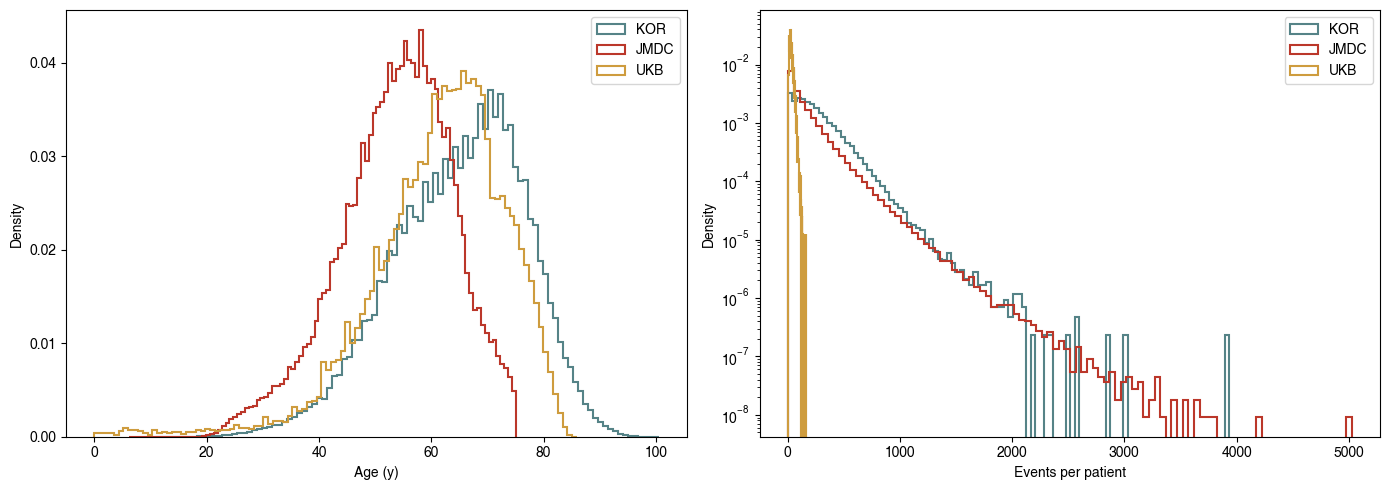

In [36]:
legend_order = ['KOR', 'JMDC', 'UKB']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, obj in domains.items():
    ages_year = obj['data']['AGE'].astype(np.float64) / 365.25
    ages_year = ages_year[ages_year > 0] 
    axes[0].hist(ages_year, bins=100, histtype='step', density=True, linewidth=1.5, label=name, color=color_map[name])

    lengths = obj['p2i'][:, 1].astype(np.int64)
    axes[1].hist(lengths, bins=100, histtype='step', density=True, linewidth=1.5, label=name, color=color_map[name])

# axes[0].set_title('Age Distribution')
axes[0].set_xlabel('Age (y)')
axes[0].set_ylabel('Density')
axes[0].legend()

# axes[1].set_title('Trajectory Length Distribution')
axes[1].set_xlabel('Events per patient')
axes[1].set_ylabel('Density')
axes[1].set_yscale('log')
axes[1].legend()

plt.tight_layout()
plt.savefig('data_distribution.pdf', bbox_inches='tight')
plt.show()

## 2) DOSE / DURATION distribution

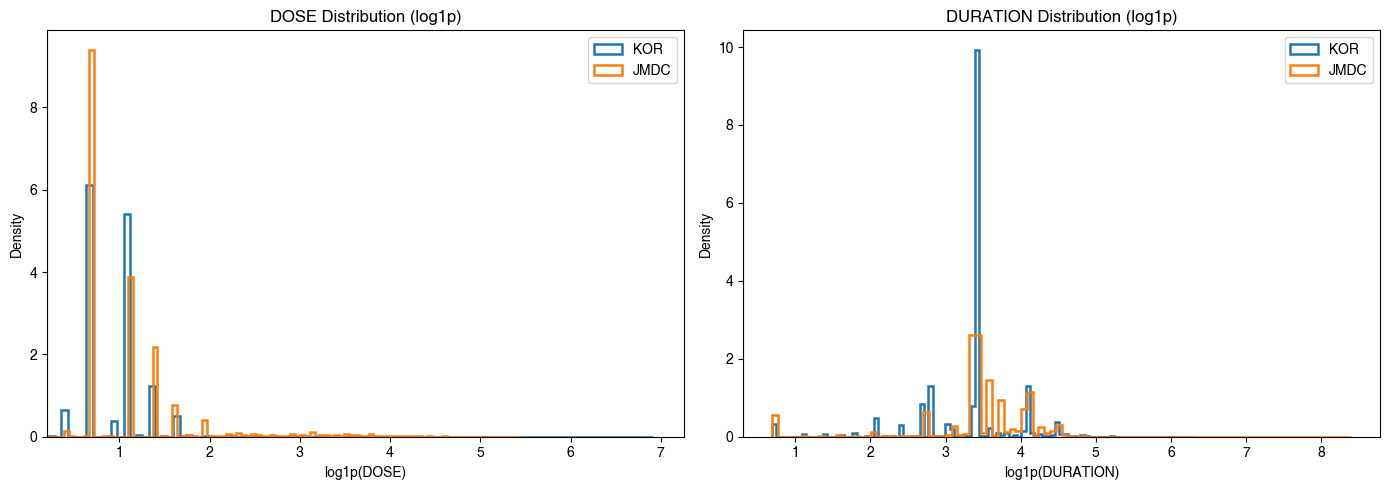

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_order = [k for k in domains.keys() if k != 'UKB']

for name in plot_order:
    obj = domains[name]
    dose = obj['data']['DOSE'].astype(np.float64)
    dur = obj['data']['DURATION'].astype(np.float64)

    dose = dose[dose > 0.01]
    dur = dur[dur > 0]

    dose_plot = np.log1p(np.clip(dose, a_min=0.0, a_max=None))
    dur_plot = np.log1p(np.clip(dur, a_min=0.0, a_max=None))

    axes[0].hist(dose_plot, bins=100, histtype='step', density=True, linewidth=1.8, label=name)
    axes[1].hist(dur_plot, bins=100, histtype='step', density=True, linewidth=1.8, label=name)

axes[0].set_title('DOSE Distribution (log1p)')
axes[0].set_xlim([0.2, None])
axes[0].set_xlabel('log1p(DOSE)')
axes[0].set_ylabel('Density')
axes[0].legend()

axes[1].set_title('DURATION Distribution (log1p)')
axes[1].set_xlabel('log1p(DURATION)')
axes[1].set_ylabel('Density')
axes[1].legend()

plt.tight_layout()
plt.show()


## 3) DATA token distribution shift

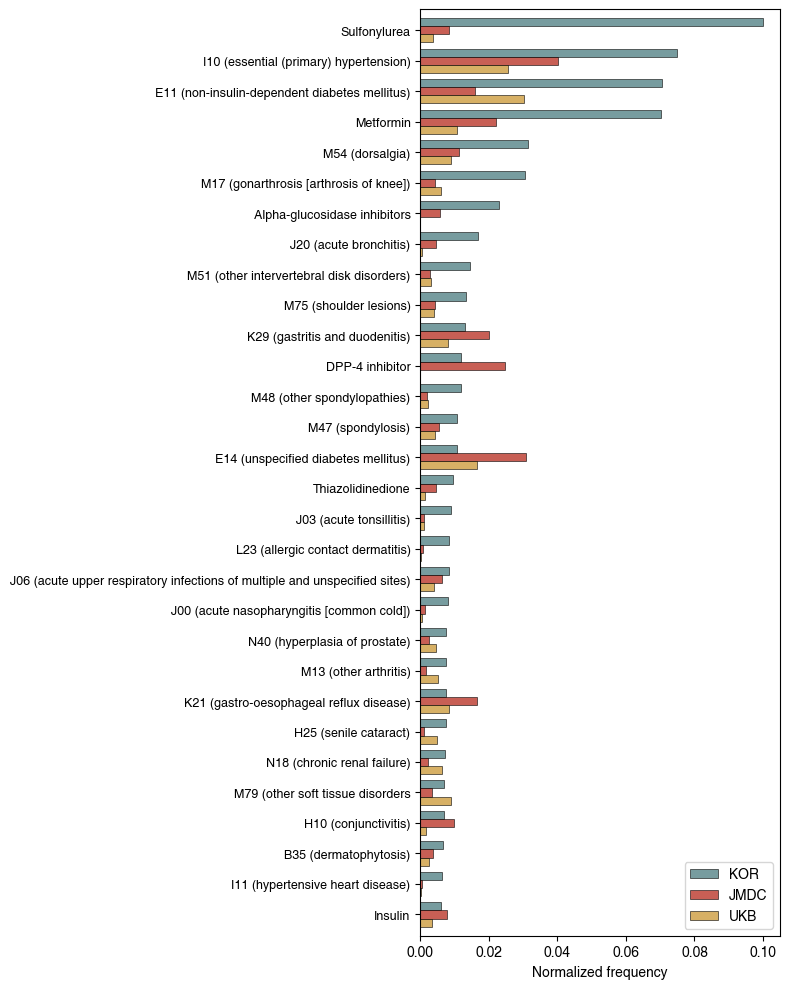

In [35]:
# reference top tokens from KR train
ref_token = domains['KOR']['data']['DATA'].astype(np.int64)
ref_counts = np.bincount(ref_token)
start_token = 22
top_k = 30

valid_tokens = np.arange(start_token, len(ref_counts))
valid_counts = ref_counts[start_token:]
top_tokens = valid_tokens[np.argsort(valid_counts)[-top_k:][::-1]]

# labels.csv 로드 (index == token id)
label_path = Path("../../data/labels.csv")
labels_df = pd.read_csv(label_path, header=None, usecols=[0], names=['name'])
labels_df['name'] = labels_df['name'].astype(str).str.strip().str.rstrip(',')
token_to_name = labels_df['name'].to_dict()  # key: token id (0-based)

def token_label(t):
    name = token_to_name.get(int(t), f"UNK_{int(t)}")
    # name = textwrap.shorten(name, width=28, placeholder="...")
    return f"{name}"

y_labels = [token_label(t) for t in top_tokens]

freq_table = {}
for name, obj in domains.items():
    token = obj['data']['DATA'].astype(np.int64)
    cnt = np.bincount(token, minlength=max(ref_counts.shape[0], top_tokens.max() + 1)).astype(np.float64)
    freq = cnt / max(cnt.sum(), 1.0)
    freq_table[name] = freq[top_tokens]

y = np.arange(top_k)
fig, ax = plt.subplots(figsize=(8, 10))
height = 0.8 / max(len(freq_table), 1)

for i, (name, freq) in enumerate(freq_table.items()):
    ax.barh(
        y + i * height,
        freq,
        height=height,
        label=name,
        alpha=0.8,
        color=color_map[name],
        edgecolor='black',
        linewidth=0.5
    )

# ax.set_title(f"Top-{top_k} Disease/Medication Tokens (from South Korea)")
ax.set_xlabel("Normalized frequency")
# ax.set_ylabel("Token ID : Label")

ax.set_yticks(y + height * (len(freq_table) - 1) / 2)
ax.set_yticklabels(y_labels, fontsize=9)
ax.invert_yaxis()
ax.margins(y=0.01)

ax.legend()
plt.tight_layout()
plt.savefig('token_distribution.pdf', bbox_inches='tight')
plt.show()

## 4) Distance metrics (vs KR train)

In [10]:
ref = domains['KOR']['data']
ref_token = ref['DATA'].astype(np.int64)
# SHIFT is discrete (e.g. 0–3); log1p is unnecessary
ref_dose = ref['SHIFT'].astype(np.float64)
ref_dur = np.log1p(np.clip(ref['TOTAL'].astype(np.int64), a_min=0.0, a_max=None))

token_bins = np.arange(max(int(ref_token.max()) + 2, 1300))
_shift_edges = max(int(ref_dose.max()) + 2, 5)
dose_bins = np.arange(0, _shift_edges)
dur_bins = np.linspace(0.0, max(np.percentile(ref_dur, 99.9), 1.0), 120)

ref_token_h = normalized_hist(ref_token, token_bins)
ref_dose_h = normalized_hist(ref_dose, dose_bins)
ref_dur_h = normalized_hist(ref_dur, dur_bins)

rows = []
for name, obj in domains.items():
    if name == 'KOR':
        continue
    d = obj['data']
    token = d['DATA'].astype(np.int64)
    dose = d['SHIFT'].astype(np.float64)
    dur = np.log1p(np.clip(d['TOTAL'].astype(np.int64), a_min=0.0, a_max=None))

    token_h = normalized_hist(token, token_bins)
    dose_h = normalized_hist(dose, dose_bins)
    dur_h = normalized_hist(dur, dur_bins)

    row = {
        'domain': name,
        'jsd_data_token': float(js_divergence(ref_token_h, token_h)),
        'jsd_SHIFT': float(js_divergence(ref_dose_h, dose_h)),
        'jsd_duration_log1p': float(js_divergence(ref_dur_h, dur_h)),
    }
    if wasserstein_distance is not None:
        row['wasserstein_SHIFT'] = float(wasserstein_distance(ref_dose, dose))
        row['wasserstein_duration_log1p'] = float(wasserstein_distance(ref_dur, dur))
    else:
        row['wasserstein_SHIFT'] = np.nan
        row['wasserstein_duration_log1p'] = np.nan
    rows.append(row)

dist_df = pd.DataFrame(rows).set_index('domain').sort_values('jsd_data_token')
dist_df

,jsd_data_token,jsd_SHIFT,jsd_duration_log1p,wasserstein_SHIFT,wasserstein_duration_log1p
domain,,,,,
JMDC,0.188264,0.016077,0.041627,0.252054,0.441002
UKB,0.236183,0.084606,0.084378,0.439798,0.741620


## 5) Patient-level feature space (PCA)

In [42]:
def patient_feature_matrix(data, p2i, max_patients=5000, rng_seed=42):
    rng = np.random.default_rng(rng_seed)
    if len(p2i) == 0:
        return np.zeros((0, 9), dtype=np.float32)

    idx = np.arange(len(p2i))
    if len(idx) > max_patients:
        idx = rng.choice(idx, size=max_patients, replace=False)

    feats = []
    for i in idx:
        s, l = p2i[i]
        rec = data[s:s+l]

        age = rec['AGE'].astype(np.float64) / 365.25
        token = rec['DATA'].astype(np.int64)
        dose = np.clip(rec['SHIFT'].astype(np.int64), a_min=0.0, a_max=None)
        dur = rec['TOTAL'].astype(np.int64)

        gaps = np.diff(age) if len(age) > 1 else np.array([0.0])
        drug_mask = (token >= DRUG_TOKEN_MIN) & (token <= DRUG_TOKEN_MAX)

        uniq, cnt = np.unique(token, return_counts=True)
        p = cnt.astype(np.float64) / max(cnt.sum(), 1.0)
        entropy = -np.sum(p * np.log(p + 1e-12))

        feats.append([
            float(len(rec)),
            float(age.min()) if len(age) else 0.0,
            float(age.max()) if len(age) else 0.0,
            float(age.max() - age.min()) if len(age) else 0.0,
            float(np.mean(gaps)),
            float(dose.mean()),
            float(np.log1p(np.clip(dur, a_min=0.0, a_max=None)).mean()),
            float(drug_mask.mean()),
            float(entropy),
        ])

    return np.asarray(feats, dtype=np.float32)

X_list = []
y_list = []
for i, (name, obj) in enumerate(domains.items()):
    X_dom = patient_feature_matrix(
        obj["data"], obj["p2i"], max_patients=100000, rng_seed=42 + i
    )
    X_list.append(X_dom)
    y_list.append(np.full(len(X_dom), name, dtype=object))

X = np.concatenate(X_list, axis=0)
y = np.concatenate(y_list, axis=0)

pca = make_pipeline(StandardScaler(), PCA(n_components=2, random_state=42))
Z = pca.fit_transform(X)

_pca_step = pca.named_steps["pca"]
_pca_evr = _pca_step.explained_variance_ratio_
W = _pca_step.components_
_PCA_FEAT_NAMES = (
    "n_evt",
    "age_min",
    "age_max",
    "age_span",
    "gap_mean",
    "mean_SHIFT",
    "log1p_TOTAL",
    "p_drug",
    "H_tok",
)

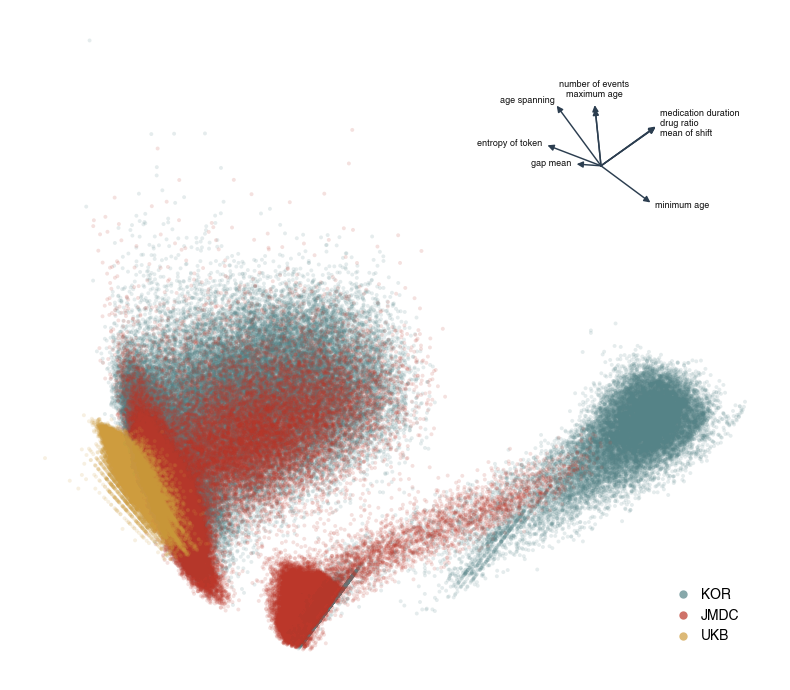

In [46]:
# color_map = {"KOR": "#1f77b4", "JMDC": "#d62728", "UKB": "#f1c523"}
legend_order = ["KOR", "JMDC", "UKB"]

fig, ax = plt.subplots(figsize=(8, 7))

for name in legend_order:
    m = y == name
    if not np.any(m):
        continue
    ax.scatter(
        Z[m, 0],
        Z[m, 1],
        s=8,
        alpha=0.15,
        c=color_map[name],
        label=name,
        edgecolors="none",
        rasterized=False,
        zorder=3,
    )

ax.set_xticks([])
ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_visible(False)

_lim_core = float(np.abs(W).max()) * 1.35 + 0.05
_lim = _lim_core * 1.30

_PCA_INSET_LABELS = (
    "number of events",
    "minimum age",
    "maximum age",
    "age spanning",
    "gap mean",
    "mean of shift",
    "medication duration",
    "drug ratio",
    "entropy of token",
)
n_feat = len(_PCA_INSET_LABELS)
arrow_scale = 0.78
tip_out = 0.05 * _lim_core
ANGLE_MERGE_DEG = 16.0
RADIAL_MERGE_FRAC = 0.072
PERP_MERGE_FRAC = 0.05

angles = np.arctan2(W[1, :n_feat].astype(np.float64), W[0, :n_feat].astype(np.float64))


def _union_find_cluster(n, pairs):
    parent = list(range(n))

    def find(i):
        while parent[i] != i:
            parent[i] = parent[parent[i]]
            i = parent[i]
        return i

    def union(a, b):
        ra, rb = find(a), find(b)
        if ra != rb:
            parent[rb] = ra

    for a, b in pairs:
        union(a, b)
    buckets = {}
    for i in range(n):
        r = find(i)
        buckets.setdefault(r, []).append(i)
    return list(buckets.values())


thr = np.deg2rad(ANGLE_MERGE_DEG)
_radial_max = float(RADIAL_MERGE_FRAC * _lim_core)
_perp_max = float(PERP_MERGE_FRAC * _lim_core)
merge_pairs = []
for i in range(n_feat):
    for j in range(i + 1, n_feat):
        da = abs((angles[i] - angles[j] + np.pi) % (2 * np.pi) - np.pi)
        if da >= thr:
            continue
        wi = W[0:2, i].astype(np.float64)
        wj = W[0:2, j].astype(np.float64)
        wsum = wi + wj
        wsn = float(np.linalg.norm(wsum))
        if wsn < 1e-12:
            uij = wi / (float(np.linalg.norm(wi)) + 1e-12)
        else:
            uij = wsum / wsn
        vij = np.array([-float(uij[1]), float(uij[0])])
        ti = np.array([float(W[0, i] * arrow_scale), float(W[1, i] * arrow_scale)])
        tj = np.array([float(W[0, j] * arrow_scale), float(W[1, j] * arrow_scale)])
        if abs(float(ti @ uij - tj @ uij)) > _radial_max:
            continue
        if abs(float(ti @ vij - tj @ vij)) > _perp_max:
            continue
        merge_pairs.append((i, j))

clusters = _union_find_cluster(n_feat, merge_pairs)
clusters.sort(key=lambda g: min(g))


def _nudge_inset_label_overlaps(fig, ax, texts, pad_pt=2.0, step_pt=1.15, max_iter=48):
    import numpy as np
    from matplotlib.transforms import Bbox

    if len(texts) < 2:
        return

    def _inflate(b):
        return Bbox([[b.x0 - pad_pt, b.y0 - pad_pt], [b.x1 + pad_pt, b.y1 + pad_pt]])

    def _ov(b1, b2):
        return not (b1.x1 < b2.x0 or b2.x1 < b1.x0 or b1.y1 < b2.y0 or b2.y1 < b1.y0)

    for _ in range(max_iter):
        fig.canvas.draw()
        rnd = fig.canvas.get_renderer()
        boxes = [_inflate(t.get_window_extent(renderer=rnd)) for t in texts]
        pair = None
        for ii in range(len(texts)):
            for jj in range(ii + 1, len(texts)):
                if _ov(boxes[ii], boxes[jj]):
                    pair = (ii, jj)
                    break
            if pair:
                break
        if not pair:
            return
        ii, jj = pair
        ai = boxes[ii].width * boxes[ii].height
        aj = boxes[jj].width * boxes[jj].height
        mov, oth = (ii, jj) if ai <= aj else (jj, ii)
        bm, bo = boxes[mov], boxes[oth]
        cm = np.array([bm.x0 + bm.width / 2, bm.y0 + bm.height / 2], dtype=np.float64)
        co = np.array([bo.x0 + bo.width / 2, bo.y0 + bo.height / 2], dtype=np.float64)
        d = cm - co
        dn = float(np.hypot(d[0], d[1]))
        if dn < 0.5:
            d = np.array([step_pt, 0.0], dtype=np.float64)
        else:
            d = (d / dn) * step_pt
        x, y = texts[mov].get_position()
        px, py = ax.transData.transform((x, y))
        xn, yn = ax.transData.inverted().transform((float(px + d[0]), float(py + d[1])))
        texts[mov].set_position((float(xn), float(yn)))


import matplotlib.lines as mlines

handles = [
    mlines.Line2D(
        [], [],
        marker="o",
        linestyle="None",
        markerfacecolor=color_map[name],
        markeredgecolor="none",
        alpha=0.7,
        markersize=3,
        label=name,
    )
    for name in legend_order
]
ax.legend(
    handles=handles,
    markerscale=2,
    loc="lower right",
    bbox_to_anchor=(0, 0.04, 0.96, 0.95),
    frameon=False,
    handletextpad=0.3,
    borderaxespad=0.3,
)

plt.tight_layout()

# inset_axes(host 자식)은 산점도가 통째로 안 보이는 경우가 있음 → figure 좌표 형제 축
_pb = ax.get_position()
_INSET_FRAC = 0.44
_INSET_PAD = 0.012
_iw = _pb.width * _INSET_FRAC
_ih = _pb.height * _INSET_FRAC
_axinl = _pb.x1 - _iw - _INSET_PAD
_axinb = _pb.y1 - _ih - _INSET_PAD
axins = fig.add_axes((_axinl, _axinb, _iw, _ih), zorder=10)
axins.set_facecolor("none")
axins.patch.set_alpha(0.0)
axins.patch.set_edgecolor("none")
axins.patch.set_visible(False)
axins.set_frame_on(False)

inset_texts = []
for g in clusters:
    tips = np.array([[float(W[0, j] * arrow_scale), float(W[1, j] * arrow_scale)] for j in g])
    wx = float(np.mean([float(W[0, j]) for j in g]))
    wy = float(np.mean([float(W[1, j]) for j in g]))
    wmn = float(np.hypot(wx, wy))
    if wmn < 1e-12:
        udir = np.array([1.0, 0.0])
    else:
        udir = np.array([wx, wy]) / wmn
    proj = tips @ udir
    far_tip = tips[int(np.argmax(proj))]
    pos = far_tip + udir * tip_out
    ux, uy = float(udir[0]), float(udir[1])
    if abs(ux) >= abs(uy):
        ha = "left" if ux > 0 else "right"
        va = "center"
    else:
        va = "bottom" if uy > 0 else "top"
        ha = "center"
    tips_by = {j: np.array([float(W[0, j] * arrow_scale), float(W[1, j] * arrow_scale)]) for j in g}
    proj_by = {j: float(tips_by[j] @ udir) for j in g}
    g_ord = sorted(g, key=lambda k: proj_by[k])
    lines = chr(10).join(_PCA_INSET_LABELS[j] for j in g_ord)
    _lspace = 1.14 if len(g) > 1 else 1.08
    for j in g:
        x1, y1 = float(W[0, j]), float(W[1, j])
        tx, ty = x1 * arrow_scale, y1 * arrow_scale
        axins.annotate(
            "",
            xy=(tx, ty),
            xytext=(0.0, 0.0),
            arrowprops=dict(
                arrowstyle="-|>",
                color="#2c3e50",
                lw=1.05,
                shrinkA=0,
                shrinkB=0,
                mutation_scale=9,
            ),
            zorder=6,
        )
    inset_texts.append(
        axins.text(
            float(pos[0]),
            float(pos[1]),
            lines,
            fontsize=6.5,
            linespacing=_lspace,
            color="#111",
            ha=ha,
            va=va,
            zorder=7,
        )
    )

axins.set_xlim(-_lim, _lim)
axins.set_ylim(-_lim, _lim)
axins.set_aspect("equal", adjustable="box")
axins.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
for s in axins.spines.values():
    s.set_visible(False)

_nudge_inset_label_overlaps(fig, axins, inset_texts)
plt.savefig("pca.pdf", bbox_inches="tight")
plt.show()

## 6) Domain separability (KR train vs each domain)

In [45]:
# reuse patient features per domain
feature_by_domain = {}
for i, (name, obj) in enumerate(domains.items()):
    feature_by_domain[name] = patient_feature_matrix(obj['data'], obj['p2i'], max_patients=100000, rng_seed=123 + i)

ref_name = 'KOR'
X_ref = feature_by_domain[ref_name]

rows = []
for name, X_dom in feature_by_domain.items():
    if name == ref_name:
        continue

    n = min(len(X_ref), len(X_dom))
    if n < 100:
        continue

    X_pair = np.vstack([X_ref[:n], X_dom[:n]])
    y_pair = np.hstack([np.zeros(n, dtype=np.int64), np.ones(n, dtype=np.int64)])

    X_tr, X_te, y_tr, y_te = train_test_split(
        X_pair, y_pair, test_size=0.25, random_state=42, stratify=y_pair
    )

    clf = make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=1000, class_weight='balanced')
    )
    clf.fit(X_tr, y_tr)
    p = clf.predict_proba(X_te)[:, 1]
    auc = roc_auc_score(y_te, p)

    rows.append({'target_domain': name, 'domain_auc_vs_kr_train': float(auc), 'n_per_domain': int(n)})

sep_df = pd.DataFrame(rows).sort_values('domain_auc_vs_kr_train', ascending=False)
sep_df


,target_domain,domain_auc_vs_kr_train,n_per_domain
1,UKB,0.999565,51072
0,JMDC,0.851750,100000


## 해석 가이드

- `jsd_*`, `wasserstein_*`가 클수록 분포 차이가 큽니다.
- `domain_auc_vs_kr_train`가 0.5에 가까우면 도메인 구분이 어렵고, 1.0에 가까우면 shift가 큽니다.
- JMDC에서 shift가 큰 축(예: duration tail, drug token mix)을 먼저 target해서 domain adaptation 전략을 설계하세요.


## 7) Conditional Shift Probe (P(y|x) shift)

아래 섹션은 KR vs JMDC에서 **같은 x 조건에서 y(dose/duration)가 달라지는지**를 점검합니다.

- Reweighting test (KR을 JMDC의 x 분포로 보정)
- Same-score curve (같은 예측점수 구간에서의 평균 y 비교)
- Matched pair test (x 최근접 매칭 후 y 차이)


In [28]:
from sklearn.ensemble import HistGradientBoostingClassifier, HistGradientBoostingRegressor
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler

def build_drug_event_table(data, p2i):
    rows = []
    for (start, length) in p2i:
        rec = data[start:start+length]
        drug_count = 0
        for i in range(length):
            tok = int(rec['DATA'][i])
            if not (DRUG_TOKEN_MIN <= tok <= DRUG_TOKEN_MAX):
                continue

            age = float(rec['AGE'][i]) / 365.25
            dose = float(max(rec['DOSE'][i], 0.0))
            dur = float(rec['DURATION'][i])

            if i > 0:
                prev_age = float(rec['AGE'][i-1]) / 365.25
                prev_gap = max(age - prev_age, 0.0)
                prev_tok = int(rec['DATA'][i-1])
                prev_dose = float(max(rec['DOSE'][i-1], 0.0))
                prev_dur = float(rec['DURATION'][i-1])
            else:
                prev_gap = 0.0
                prev_tok = 0
                prev_dose = 0.0
                prev_dur = 0.0

            drug_count += 1
            pos_norm = float(i / max(length - 1, 1))
            drug_rate_so_far = float(drug_count / (i + 1))

            rows.append({
                'token': tok,
                'age': age,
                'prev_gap': prev_gap,
                'prev_tok': prev_tok,
                'prev_dose': prev_dose,
                'prev_dur': prev_dur,
                'event_pos_norm': pos_norm,
                'drug_rate_so_far': drug_rate_so_far,
                'traj_len': float(length),
                'dose_y': dose,
                'dur_y': dur,
            })

    return pd.DataFrame(rows)

def _safe_rmse(y, p, w=None):
    y = np.asarray(y, dtype=np.float64)
    p = np.asarray(p, dtype=np.float64)
    if w is None:
        return float(np.sqrt(mean_squared_error(y, p)))
    w = np.asarray(w, dtype=np.float64)
    e2 = (y - p) ** 2
    return float(np.sqrt(np.average(e2, weights=w)))

def _binned_curve(pred, y, n_bins=10):
    pred = np.asarray(pred, dtype=np.float64)
    y = np.asarray(y, dtype=np.float64)
    qs = np.linspace(0, 1, n_bins + 1)
    bins = np.quantile(pred, qs)
    bins = np.unique(bins)
    if len(bins) < 3:
        return pd.DataFrame(columns=['bin_left', 'bin_right', 'mean_pred', 'mean_y', 'n'])

    idx = np.digitize(pred, bins[1:-1], right=False)
    rows = []
    for b in range(len(bins) - 1):
        m = idx == b
        if m.sum() == 0:
            continue
        rows.append({
            'bin_left': float(bins[b]),
            'bin_right': float(bins[b + 1]),
            'mean_pred': float(pred[m].mean()),
            'mean_y': float(y[m].mean()),
            'n': int(m.sum()),
        })
    return pd.DataFrame(rows)

def conditional_shift_probe(X_kr, y_kr, X_jm, y_jm, random_state=42):
    # Domain classifier: p(domain=JMDC | x)
    X_dom = np.vstack([X_kr, X_jm])
    d_dom = np.hstack([np.zeros(len(X_kr), dtype=np.int64), np.ones(len(X_jm), dtype=np.int64)])

    dom_clf = HistGradientBoostingClassifier(max_depth=6, learning_rate=0.05, max_iter=300, random_state=random_state)
    dom_clf.fit(X_dom, d_dom)
    dom_prob = dom_clf.predict_proba(X_dom)[:, 1]
    auc_domain = roc_auc_score(d_dom, dom_prob)

    # KR-only y model
    y_model = HistGradientBoostingRegressor(max_depth=6, learning_rate=0.05, max_iter=400, random_state=random_state)
    y_model.fit(X_kr, y_kr)

    p_kr = y_model.predict(X_kr)
    p_jm = y_model.predict(X_jm)

    # Importance weighting KR -> JMDC(x): w = p(domain=JMDC|x) / p(domain=KR|x)
    pj_kr = np.clip(dom_clf.predict_proba(X_kr)[:, 1], 1e-4, 1.0 - 1e-4)
    w_kr_to_jm = np.clip(pj_kr / (1.0 - pj_kr), 0.05, 20.0)

    # Main metrics
    rmse_kr = _safe_rmse(y_kr, p_kr)
    rmse_kr_rw = _safe_rmse(y_kr, p_kr, w=w_kr_to_jm)
    rmse_jm = _safe_rmse(y_jm, p_jm)

    mae_kr = float(mean_absolute_error(y_kr, p_kr))
    mae_jm = float(mean_absolute_error(y_jm, p_jm))

    # Same-score curves
    curve_kr = _binned_curve(p_kr, y_kr, n_bins=10)
    curve_jm = _binned_curve(p_jm, y_jm, n_bins=10)

    # Matched pair (nearest neighbors in x)
    scaler = StandardScaler()
    X_kr_s = scaler.fit_transform(X_kr)
    X_jm_s = scaler.transform(X_jm)
    nn = NearestNeighbors(n_neighbors=1, metric='euclidean')
    nn.fit(X_kr_s)
    _, idx = nn.kneighbors(X_jm_s, return_distance=True)
    y_kr_match = y_kr[idx[:, 0]]
    delta = y_jm - y_kr_match

    summary = {
        'auc_domain_from_x': float(auc_domain),
        'rmse_kr_raw': rmse_kr,
        'rmse_kr_reweighted_to_jmdc_x': rmse_kr_rw,
        'rmse_jmdc': rmse_jm,
        'rmse_gap_after_reweight': float(rmse_jm - rmse_kr_rw),
        'mae_kr_raw': mae_kr,
        'mae_jmdc': mae_jm,
        'matched_delta_mean_jmdc_minus_kr': float(delta.mean()),
        'matched_delta_std': float(delta.std()),
        'matched_delta_p05': float(np.percentile(delta, 5)),
        'matched_delta_p50': float(np.percentile(delta, 50)),
        'matched_delta_p95': float(np.percentile(delta, 95)),
    }

    return summary, curve_kr, curve_jm


In [50]:
assert 'KOR' in domains and 'JMDC' in domains, 'KOR and JMDC must be loaded.'

df_kr = build_drug_event_table(domains['KOR']['data'], domains['KOR']['p2i'])
df_jm = build_drug_event_table(domains['JMDC']['data'], domains['JMDC']['p2i'])

print('KOR drug events :', len(df_kr))
print('JMDC drug events:', len(df_jm))

feature_cols = [
    'token', 'age', 'prev_gap', 'prev_tok', 'prev_dose', 'prev_dur',
    'event_pos_norm', 'drug_rate_so_far', 'traj_len'
]

X_kr = df_kr[feature_cols].to_numpy(dtype=np.float32)
X_jm = df_jm[feature_cols].to_numpy(dtype=np.float32)

# SHIFT / dose_y probe (raw 0–3; log1p 불필요)
y_dose_kr = df_kr['dose_y'].to_numpy(dtype=np.float64)
y_dose_jm = df_jm['dose_y'].to_numpy(dtype=np.float64)

dose_summary, dose_curve_kr, dose_curve_jm = conditional_shift_probe(X_kr, y_dose_kr, X_jm, y_dose_jm)

# DURATION probe (log1p scale)
y_dur_kr = np.log1p(np.clip(df_kr['dur_y'].to_numpy(dtype=np.float64), a_min=0.0, a_max=None))
y_dur_jm = np.log1p(np.clip(df_jm['dur_y'].to_numpy(dtype=np.float64), a_min=0.0, a_max=None))

dur_summary, dur_curve_kr, dur_curve_jm = conditional_shift_probe(X_kr, y_dur_kr, X_jm, y_dur_jm)

probe_df = pd.DataFrame([
    {'target': 'SHIFT', **dose_summary},
    {'target': 'duration_log1p', **dur_summary},
]).set_index('target')
probe_df


KOR drug events : 5757144
JMDC drug events: 30437277


,auc_domain_from_x,rmse_kr_raw,rmse_kr_reweighted_to_jmdc_x,rmse_jmdc,rmse_gap_after_reweight,mae_kr_raw,mae_jmdc,matched_delta_mean_jmdc_minus_kr,matched_delta_std,matched_delta_p05,matched_delta_p50,matched_delta_p95
target,,,,,,,,,,,,
dose_log1p,0.997144,0.25156,0.261052,0.626470,0.365418,0.18862,0.353277,0.150661,0.716036,-0.693147,0.0,1.609438
duration_log1p,0.997144,0.37149,0.366149,1.423213,1.057064,0.19131,0.860603,0.192891,1.097048,-1.354546,0.0,2.674149


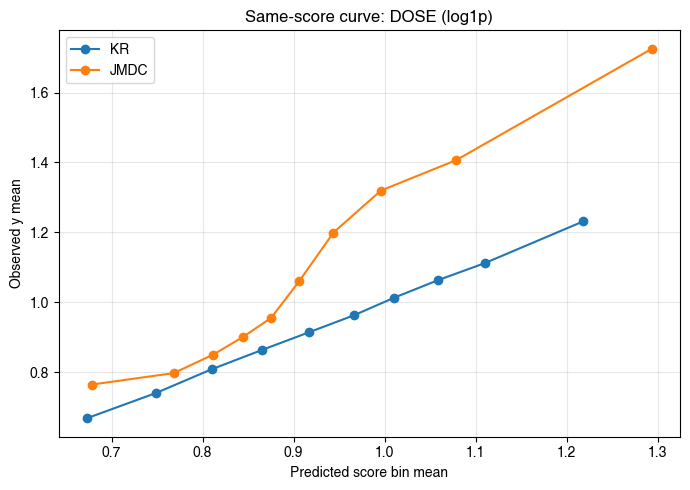

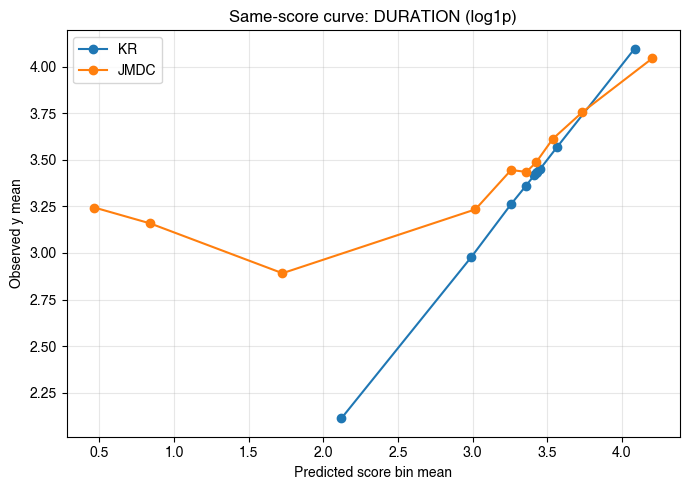

In [51]:
def plot_same_score_curve(curve_kr, curve_jm, title):
    c1 = curve_kr.copy()
    c2 = curve_jm.copy()
    if len(c1) == 0 or len(c2) == 0:
        print('[warn] empty curve')
        return

    plt.figure(figsize=(7, 5))
    plt.plot(c1['mean_pred'], c1['mean_y'], marker='o', label='KR')
    plt.plot(c2['mean_pred'], c2['mean_y'], marker='o', label='JMDC')
    plt.xlabel('Predicted score bin mean')
    plt.ylabel('Observed y mean')
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_same_score_curve(dose_curve_kr, dose_curve_jm, 'Same-score curve: SHIFT')
plot_same_score_curve(dur_curve_kr, dur_curve_jm, 'Same-score curve: DURATION (log1p)')

In [52]:
probe_df.to_csv('probe_summary.csv', index=False)

### Conditional Shift 해석 팁

- `auc_domain_from_x`가 높으면 `x` 분포 차이(covariate shift)가 큽니다.
- `rmse_kr_reweighted_to_jmdc_x`로 보정했는데도 `rmse_jmdc`가 크게 나쁘면 `P(y|x)` 차이 가능성이 큽니다.
- `matched_delta_mean_jmdc_minus_kr`가 지속적으로 음수/양수이면 같은 x에서도 처방 관행이 다를 수 있습니다.
- same-score curve에서 KR/JMDC 라인이 벌어지면 conditional shift 신호입니다.
